# Studio 2 — Feel the Explosion: the Stamford delivery tour 🚚💥

**OPIM 5641 · Business Decision Modeling · Dr. Dave Wanik, UConn**

You run deliveries out of **UConn Stamford**. Every morning the van visits every stop once, comes
back, and should drive the **fewest miles**. Brute force has a simple plan: try every order, keep
the shortest. Tonight you watch that plan **work beautifully** — and then **hit a wall**.

**Two teams, two maps, same code.**
- **Team A** heads west: Greenwich, Cos Cob, Port Chester, Rye, Armonk.
- **Team B** heads north and east: Darien, New Canaan, Norwalk, Westport, Ridgefield.

Distances are real driving miles (OpenStreetMap routing), rounded to whole miles.

We go in five escalations:
1. **The paper tour**: 3 stops, the one you did by hand
2. ✅ **Success**: 5 stops, 120 routes, instant
3. **The ramp**: time it from 4 stops up to 10
4. ❌ **The wall**: all 12 stops — estimate before you run
5. **The escape hatch**: a greedy rule that's instant but not perfect

## 0 · Pick your team

In [1]:
TEAM = 'A'   # 👈 your team letter from the card: 'A' or 'B'

import time, math, itertools
import pandas as pd
import matplotlib.pyplot as plt

base = 'https://raw.githubusercontent.com/drdave-teaching/OPIM5641-notebooks/main/studio2/'
stops = pd.read_csv(base + 'stamford_stops.csv')
stops = stops[stops['team'] == TEAM].reset_index(drop=True)
miles = pd.read_csv(base + f'stamford_miles_{TEAM}.csv', index_col=0)

D = miles.values.tolist()     # D[i][j] = driving miles from stop i to stop j  (stop 0 = the depot)
names = list(miles.index)
stops

,team,stop_id,stop,lat,lon
0,A,0,UConn Stamford (depot),41.0535,-73.5413
1,A,1,"Greenwich Ave, Greenwich",41.0262,-73.6282
2,A,2,Old Greenwich,41.0229,-73.5687
3,A,3,Cos Cob,41.0334,-73.5993
4,A,4,"Shippan Point, Stamford",41.0386,-73.5290
5,A,5,"Glenbrook, Stamford",41.0707,-73.5218
6,A,6,"Springdale, Stamford",41.0876,-73.5268
7,A,7,North Stamford,41.1380,-73.5430
8,A,8,"Port Chester, NY",41.0018,-73.6657
9,A,9,"Rye, NY",40.9807,-73.6837


In [2]:
miles.iloc[:4, :4]   # the corner of the table on your paper card — same numbers

,UConn Stamford (depot),"Greenwich Ave, Greenwich",Old Greenwich,Cos Cob
from,,,,
UConn Stamford (depot),0,6,4,4
"Greenwich Ave, Greenwich",6,0,5,2
Old Greenwich,4,5,0,4
Cos Cob,4,2,4,0


## 1 · See the map

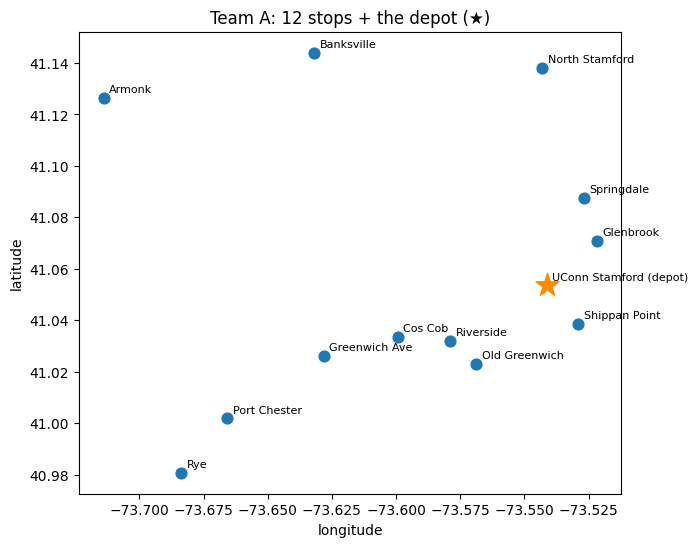

In [3]:
def draw(route=None, title='', fname=None):
    plt.figure(figsize=(7, 6))
    plt.scatter(stops['lon'][1:], stops['lat'][1:], s=60)
    plt.scatter(stops['lon'][0], stops['lat'][0], marker='*', s=300, color='darkorange', zorder=3)
    for i, row in stops.iterrows():
        plt.annotate(row['stop'].split(',')[0], (row['lon'], row['lat']),
                     fontsize=8, xytext=(4, 4), textcoords='offset points')
    if route is not None:
        loop = [0] + list(route) + [0]
        plt.plot(stops['lon'][loop], stops['lat'][loop], color='darkorange')
    plt.title(title); plt.xlabel('longitude'); plt.ylabel('latitude')
    if fname:
        plt.savefig(fname)
    plt.show()

draw(title=f'Team {TEAM}: 12 stops + the depot (★)')

## 2 · The paper tour (you did this by hand)

Depot + 3 stops. How many orders? **3 × 2 × 1 = 6.** Every loop shows up twice (once in each
direction), so there are only **3 different lengths**. Check your card against the computer.

In [4]:
def tour_length(route):
    """Miles for: depot -> each stop in order -> back to the depot."""
    loop = [0] + list(route) + [0]
    total = 0
    for a, b in zip(loop, loop[1:]):
        total = total + D[a][b]
    return total

for route in itertools.permutations([1, 2, 3]):
    print([names[i] for i in route], tour_length(route), 'miles')

['Greenwich Ave, Greenwich', 'Old Greenwich', 'Cos Cob'] 19 miles
['Greenwich Ave, Greenwich', 'Cos Cob', 'Old Greenwich'] 16 miles
['Old Greenwich', 'Greenwich Ave, Greenwich', 'Cos Cob'] 15 miles
['Old Greenwich', 'Cos Cob', 'Greenwich Ave, Greenwich'] 16 miles
['Cos Cob', 'Greenwich Ave, Greenwich', 'Old Greenwich'] 15 miles
['Cos Cob', 'Old Greenwich', 'Greenwich Ave, Greenwich'] 19 miles


`itertools.permutations([1, 2, 3])` hands you every order — exactly the list you wrote on
paper. It's tonight's brute-force engine.

## 3 · ✅ Success: 5 stops, 120 routes

checked 120 routes in 0.0015 seconds
best: UConn Stamford (depot) -> Old Greenwich -> Greenwich Ave, Greenwich -> Cos Cob -> Shippan Point, Stamford -> Glenbrook, Stamford -> UConn Stamford (depot) = 21 miles


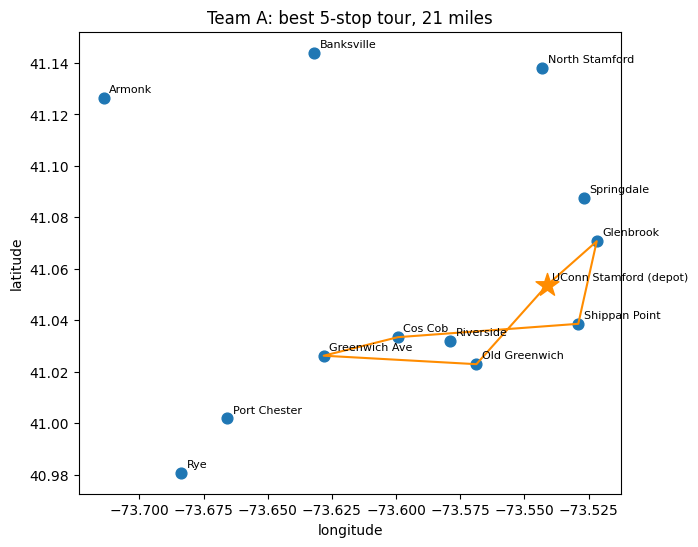

In [5]:
stops_today = [1, 2, 3, 4, 5]

start = time.time()
best_route, best_miles, count = None, float('inf'), 0
for route in itertools.permutations(stops_today):
    count = count + 1
    m = tour_length(route)
    if m < best_miles:                      # keep the best one we've seen so far
        best_route, best_miles = route, m
elapsed = time.time() - start

print(f'checked {count:,} routes in {elapsed:.4f} seconds')
print('best:', ' -> '.join(names[i] for i in (0,) + best_route + (0,)), f'= {best_miles} miles')
draw(best_route, f'Team {TEAM}: best 5-stop tour, {best_miles} miles')

Instant, and **guaranteed** to be the best. That's why brute force is so tempting.
So let's put it in a function and start adding stops.

In [6]:
def brute_force(stop_list):
    best_route, best_miles, count = None, float('inf'), 0
    for route in itertools.permutations(stop_list):
        count = count + 1
        m = tour_length(route)
        if m < best_miles:
            best_route, best_miles = route, m
    return best_route, best_miles, count

## 4 · The ramp: add one stop at a time

**Predict before you run:** going from 9 stops to 10, how many times more work is that? ____

In [7]:
results = []
for n in range(4, 11):       # 4, 5, ..., 10 stops — 10 takes a few seconds, watch it
    start = time.time()
    route, m, count = brute_force(list(range(1, n + 1)))
    secs = time.time() - start
    results.append({'stops': n, 'routes_checked': count, 'seconds': round(secs, 3), 'best_miles': m})
    print(f'{n:>2} stops: {count:>10,} routes  {secs:8.3f} s   best = {m} mi')

ramp = pd.DataFrame(results)
ramp

 4 stops:         24 routes     0.000 s   best = 18 mi
 5 stops:        120 routes     0.001 s   best = 21 mi
 6 stops:        720 routes     0.003 s   best = 24 mi
 7 stops:      5,040 routes     0.016 s   best = 31 mi
 8 stops:     40,320 routes     0.156 s   best = 37 mi


 9 stops:    362,880 routes     1.359 s   best = 41 mi


10 stops:  3,628,800 routes    13.141 s   best = 50 mi


,stops,routes_checked,seconds,best_miles
0,4,24,0.000,18
1,5,120,0.001,21
2,6,720,0.003,24
3,7,5040,0.016,31
4,8,40320,0.156,37
5,9,362880,1.359,41
6,10,3628800,13.141,50


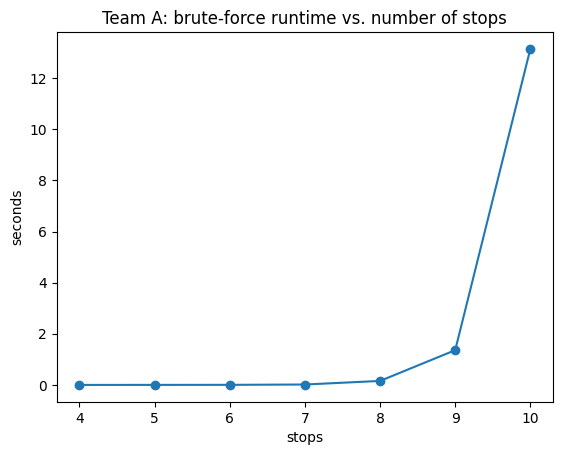

In [8]:
plt.plot(ramp['stops'], ramp['seconds'], marker='o')
plt.title(f'Team {TEAM}: brute-force runtime vs. number of stops')
plt.xlabel('stops'); plt.ylabel('seconds')
plt.savefig('fig_runtime.png')
plt.show()

Each new stop multiplies the number of routes by the new stop count: 4 stops is 4 × 3 × 2 × 1 = 24
routes, 10 stops is **3,628,800**. That's a **factorial** (written 10!). The curve doesn't just get
steep — it becomes a wall.

## 5 · ❌ The wall: all 12 stops

Twelve stops is an ordinary morning for a delivery van. **Don't run it — estimate it first,**
like you'd have to in a meeting.

In [9]:
sec_per_route = ramp['seconds'].iloc[-1] / ramp['routes_checked'].iloc[-1]
print(f'your laptop checks about {1 / sec_per_route:,.0f} routes per second\n')

def friendly(secs):
    if secs < 60:            return f'{secs:.0f} seconds'
    if secs < 3600:          return f'{secs / 60:.0f} minutes'
    if secs < 86400:         return f'{secs / 3600:.1f} hours'
    if secs < 86400 * 365:   return f'{secs / 86400:.0f} days'
    return f'{secs / 86400 / 365:,.0f} years'

for n in [11, 12, 15, 20]:
    routes = math.factorial(n)
    print(f'{n} stops: {routes:>26,} routes  ->  about {friendly(routes * sec_per_route)}')

your laptop checks about 276,143 routes per second

11 stops:                 39,916,800 routes  ->  about 2 minutes
12 stops:                479,001,600 routes  ->  about 29 minutes
15 stops:          1,307,674,368,000 routes  ->  about 55 days
20 stops:  2,432,902,008,176,640,000 routes  ->  about 279,372 years


For scale, the universe is about **13.8 billion years** old. And a real driver can have 100+ stops.

🐢 **Brave pairs only:** uncomment the cell below to run 11 stops (it takes a few minutes).
Raise your hand when it finishes and compare the time to your estimate.

In [10]:
# start = time.time()
# route11, miles11, count11 = brute_force(list(range(1, 12)))
# print(f'11 stops: {miles11} miles, {count11:,} routes, {time.time() - start:.0f} seconds')

## 6 · The escape hatch: be greedy

What a real dispatcher does: **always drive to the nearest stop you haven't visited yet.**

greedy, all 12 stops: 71 miles in 87 microseconds


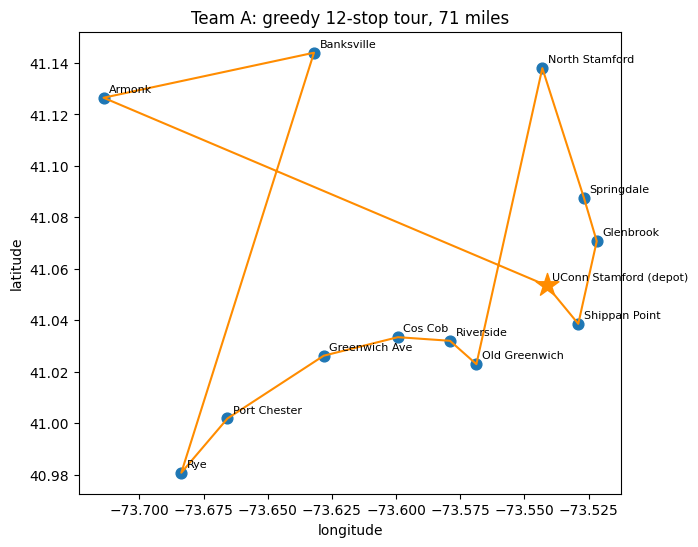

In [11]:
def nearest_neighbor(stop_list):
    route, current, left = [], 0, list(stop_list)
    while left:
        nxt = min(left, key=lambda j: D[current][j])   # closest unvisited stop
        route.append(nxt)
        left.remove(nxt)
        current = nxt
    return tuple(route)

all12 = list(range(1, 13))
start = time.perf_counter()
nn_route = nearest_neighbor(all12)
micro = (time.perf_counter() - start) * 1_000_000
print(f'greedy, all 12 stops: {tour_length(nn_route)} miles in {micro:.0f} microseconds')
draw(nn_route, f'Team {TEAM}: greedy 12-stop tour, {tour_length(nn_route)} miles', fname='fig_greedy_map.png')

How good is greedy? On 10 stops we **know** the true best, so we can grade it:

In [12]:
ten = list(range(1, 11))
optimal = ramp['best_miles'].iloc[-1]
greedy = tour_length(nearest_neighbor(ten))
print(f'10 stops: optimal {optimal} mi vs greedy {greedy} mi  ->  greedy is {100 * (greedy - optimal) / optimal:.0f}% longer')

10 stops: optimal 50 mi vs greedy 56 mi  ->  greedy is 12% longer


## 7 · Talk with your partner, then save 📝

1. **Your cliff:** at how many stops did the wait stop being acceptable?
2. **The other team** had a different map. At the wrap, compare cliffs — are they different? Why or why not?
3. Greedy was instant but some percent longer. **When would you take that deal**, and when wouldn't you?

**Save:** File → *Save a copy in GitHub* → your `opim5641-work` repo, plus the two figures
(`fig_runtime.png`, `fig_greedy_map.png`).

*The hook:* an LP has **infinitely** many possible answers, yet the graphical method only checks a
handful of **corners**. That's what a smarter method looks like — and it's where we go next.